<a href="https://colab.research.google.com/github/purnimamarasinghe2005-lgtm/BI-and-Data-Mining/blob/main/Final_Business_Intelligence_and_Data_Mining_1_4_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Early Readmission of Diabetic Patients: A Business Intelligence Analysis of 130 US Hospitals (1999–2008)

**Module:** Business Intelligence and Data Mining (UFCFMM)  
**Assessment:** Task 2 – Group Project Portfolio  

**Group Members:**  
AL Wai Lwin Chan  
Sin Thier  
Sadeep Madushan Yati Kindage  
Purnima Marasinghe Mudiyanselage  

**Datasets:**  
[diabetic_data.csv](https://drive.google.com/file/d/19ZaXM0NpKTD1bQaxtgKqyZR28tH6wRcq/view?usp=drive_link)  
[IDS_mapping.csv](https://drive.google.com/file/d/1J3bVU-mJaJas84V4LqSuFhhBI21U9_NY/view?usp=drive_link)


This notebook studies whether hospital encounter data can help identify diabetic patients who are likely to be readmitted within 30 days. Readmission matters from a business perspective because it affects cost, bed capacity, and quality of care. The notebook follows the full business intelligence lifecycle required in the brief: problem definition, dataset justification, preprocessing, exploratory analysis, modelling, evaluation, recommendations, and ethical reflection. The dataset is associated with the study by Strack *et al.* (2014), which supports its academic relevance.


## [1] Background of Diabetic Readmission Problem
Hospital readmission within 30 days is a significant issue in healthcare systems, particularly for patients with chronic conditions such as diabetes. These patients are more likely to experience complications, poor disease management, and comorbidities, which increase the likelihood of repeated hospitalisations (Strack et al., 2014).

High readmission rates often indicate gaps in treatment effectiveness, discharge planning, or follow-up care (Zuckerman et al., 2016).

### Business Importance
From a business perspective, high readmission rates increase operational costs, reduce hospital capacity, and negatively impact performance metrics. Hospitals may face financial penalties from regulators and insurance providers, and readmission rates are often used as indicators of service quality and efficiency (Centers for Medicare & Medicaid Services, 2023).

### Project Objectives
This project aims to develop a predictive model to identify diabetic patients at risk of 30-day readmission. The objectives are to analyse key factors influencing readmission, apply machine learning techniques, generate actionable insights, and evaluate ethical and practical implications.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from plotly import graph_objects as go
!pip install squarify
import squarify

## [2] Dataset Description

### Source of Dataset
The dataset is obtained from the UCI Machine Learning Repository and contains over 100,000 hospital encounters from multiple US hospitals between 1999 and 2008.

### Key Attributes
The dataset includes:
- Demographic variables (age, gender, race)
- Clinical variables (diagnoses, lab results, medications)
- Hospital utilisation data (inpatient, outpatient, emergency visits)
- Administrative data (admission type, discharge details)

These attributes provide a comprehensive view of patient health and hospital interactions.

### Target Variable Definition
The original readmission variable contains three categories: `<30`, `>30`, and `NO`. This is transformed into a binary variable:
- 1: readmitted within 30 days  
- 0: not readmitted within 30 days  

This simplifies modelling and aligns with the objective of identifying high-risk patients.

In [ ]:
##2 LOAD DATASETS

df = pd.read_csv("diabetic_data.csv")
ids_map = pd.read_csv("IDS_mapping.csv")

##[3] DATA CLEANING & FEATURE ENGINEERING

### [3.1] Data Cleaning
Missing values represented by “?” are converted to NaN for consistency. Several features are removed due to irrelevance or high missingness:
- encounter_id and patient_nbr (identifiers)
- weight (high missing values)
- payer_code and medical_specialty (incomplete and less relevant)

These steps reduce noise and improve data quality.

In [ ]:
df.replace('?', np.nan, inplace=True)

df.drop([
    'encounter_id','patient_nbr','weight',
    'payer_code','medical_specialty'
], axis=1, inplace=True, errors='ignore')

# Only perform conversion and drop if 'readmitted' column exists
if 'readmitted' in df.columns:
    df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == "<30" else 0)
    df.drop('readmitted', axis=1, inplace=True)

### [3.2] Feature Engineering

Key transformations include:

- Converting age groups into numerical values (age_num) to enable quantitative analysis  
- Binary encoding for variables such as medication change and diabetes medication usage to simplify categorical inputs  
- Ordinal encoding for clinical variables such as insulin dosage, A1C results, and glucose levels to preserve meaningful order  
- Grouping diagnosis codes into broader categories to reduce dimensionality while retaining clinical relevance  
- Creating a composite feature, *treatment_intensity*, by combining the number of procedures, lab tests, and medications to represent overall treatment complexity  

These transformations improve model performance by reducing noise, preserving meaningful relationships, and enabling algorithms to capture patterns more effectively.

In [ ]:
age_map = {
    "[0-10)":5,"[10-20)":15,"[20-30)":25,"[30-40)":35,"[40-50)":45,
    "[50-60)":55,"[60-70)":65,"[70-80)":75,"[80-90)":85,"[90-100)":95
}
df["age_num"] = df["age"].map(age_map)

df["change_bin"] = df["change"].replace({"Ch":1,"No":0})
df["diabetesMed_bin"] = df["diabetesMed"].replace({"Yes":1,"No":0})

A1C_map = {"Norm":0,">7":1,">8":2}
glu_map = {"Norm":0,">200":1,">300":2}
insulin_map = {"No":0,"Steady":1,"Up":2,"Down":3}

df["A1Cresult_bin"] = df["A1Cresult"].map(A1C_map)
df["max_glu_serum_bin"] = df["max_glu_serum"].map(glu_map)
df["insulin_bin"] = df["insulin"].map(insulin_map)

df["diag_1_group"] = df["diag_1"].astype(str).str[0]

df["treatment_intensity"] = (
    df["num_procedures"] +
    df["num_lab_procedures"] +
    df["num_medications"]
)

/tmp/ipykernel_34643/3556199546.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["change_bin"] = df["change"].replace({"Ch":1,"No":0})
/tmp/ipykernel_34643/3556199546.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["diabetesMed_bin"] = df["diabetesMed"].replace({"Yes":1,"No":0})


### [3.3] Final Dataset Overview
The final dataset consists of structured numerical and encoded categorical variables. Data types are consistent, and summary statistics confirm the distribution and scale of key features.

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   race                      99493 non-null   object 
 1   gender                    101766 non-null  object 
 2   age                       101766 non-null  object 
 3   admission_type_id         101766 non-null  int64  
 4   discharge_disposition_id  101766 non-null  int64  
 5   admission_source_id       101766 non-null  int64  
 6   time_in_hospital          101766 non-null  int64  
 7   num_lab_procedures        101766 non-null  int64  
 8   num_procedures            101766 non-null  int64  
 9   num_medications           101766 non-null  int64  
 10  number_outpatient         101766 non-null  int64  
 11  number_emergency          101766 non-null  int64  
 12  number_inpatient          101766 non-null  int64  
 13  diag_1                    101745 non-null  o

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted_binary,age_num,change_bin,diabetesMed_bin,A1Cresult_bin,max_glu_serum_bin,insulin_bin,treatment_intensity
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,17018.000000,5346.000000,101766.000000,101766.000000
mean,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607,0.111599,65.967022,0.461952,0.770031,1.189564,0.750655,0.885708,60.457216
std,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600,0.314874,15.940838,0.498553,0.420815,0.860297,0.812510,1.021758,23.588174
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,0.000000,55.000000,0.000000,1.000000,0.000000,0.000000,0.000000,46.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,0.000000,65.000000,0.000000,1.000000,1.000000,1.000000,1.000000,61.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,0.000000,75.000000,1.000000,1.000000,2.000000,1.000000,1.000000,76.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,1.000000,95.000000,1.000000,1.000000,2.000000,2.000000,3.000000,179.000000


##[4] Exploratory Data Analysis (EDA)

EDA is conducted to identify patterns and relationships between patient characteristics and readmission risk.(Kulkarni and Harman, 2011)

### [4.1] Target Variable Distribution
The dataset shows class imbalance, with fewer patients readmitted within 30 days. This requires careful evaluation using metrics beyond accuracy.

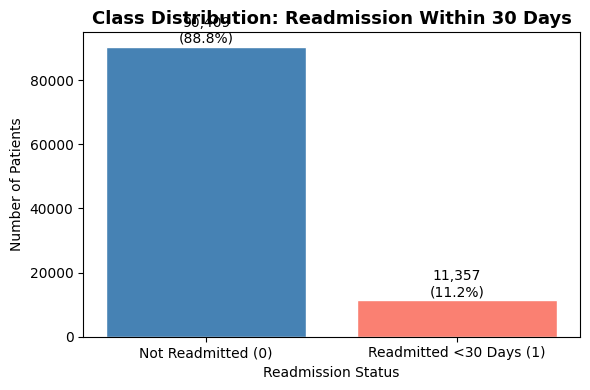

In [ ]:
# [4.1] Target Variable Distribution


plt.figure(figsize=(6, 4))
counts = df["readmitted_binary"].value_counts()
bars = plt.bar(["Not Readmitted (0)", "Readmitted <30 Days (1)"],
               [counts[0], counts[1]],
               color=["steelblue", "salmon"], edgecolor="white")

for bar, count in zip(bars, [counts[0], counts[1]]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 300,
             f'{count:,}\n({count/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10)

plt.title("Class Distribution: Readmission Within 30 Days", fontsize=13, fontweight="bold")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

### [4.2] Demographic Analysis
Older patient groups appear to have higher readmission rates, suggesting increased clinical vulnerability and the need for more structured post-discharge care strategies.(Mckinney, 2013)

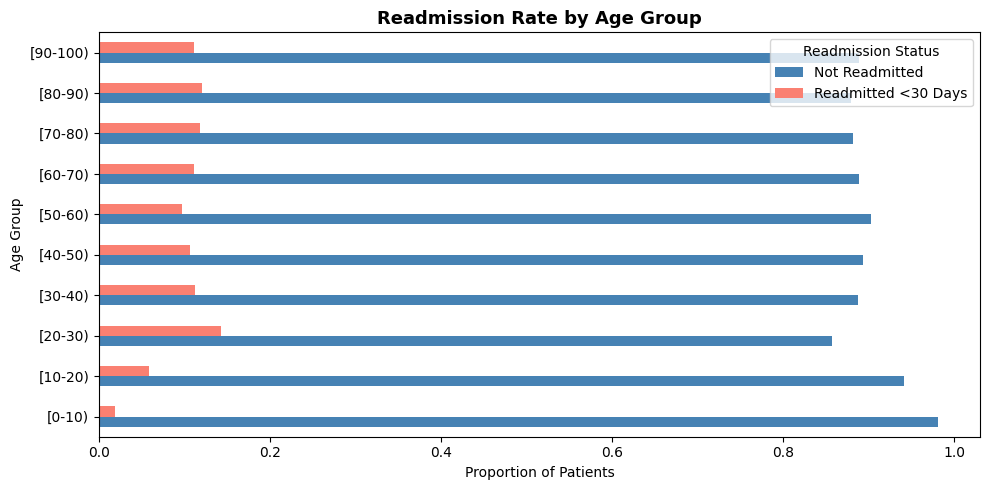

In [ ]:
# [4.2] Readmission Rate by Age Group


age_order = ["[0-10)","[10-20)","[20-30)","[30-40)","[40-50)",
             "[50-60)","[60-70)","[70-80)","[80-90)","[90-100)"]

age_tab = (
    pd.crosstab(df["age"], df["readmitted_binary"], normalize="index")
    .reindex(age_order)
)
age_tab.columns = ["Not Readmitted", "Readmitted <30 Days"]

ax = age_tab.plot(kind="barh", figsize=(10, 5), color=["steelblue", "salmon"])
plt.title("Readmission Rate by Age Group", fontsize=13, fontweight="bold")
plt.xlabel("Proportion of Patients")
plt.ylabel("Age Group")
plt.legend(title="Readmission Status")
plt.tight_layout()
plt.show()

### [4.3] Hospital Factors
Admission type, discharge disposition, and admission source influence readmission. Certain discharge types are associated with higher risk.

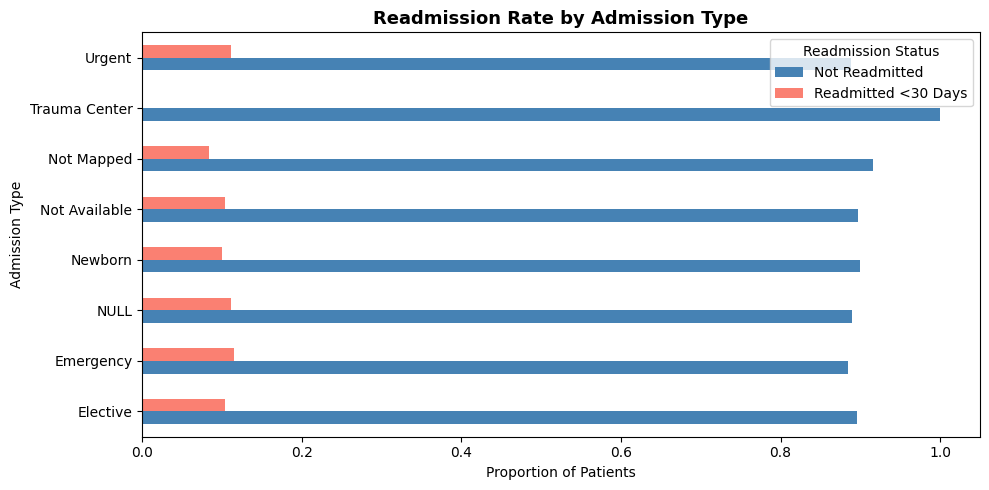

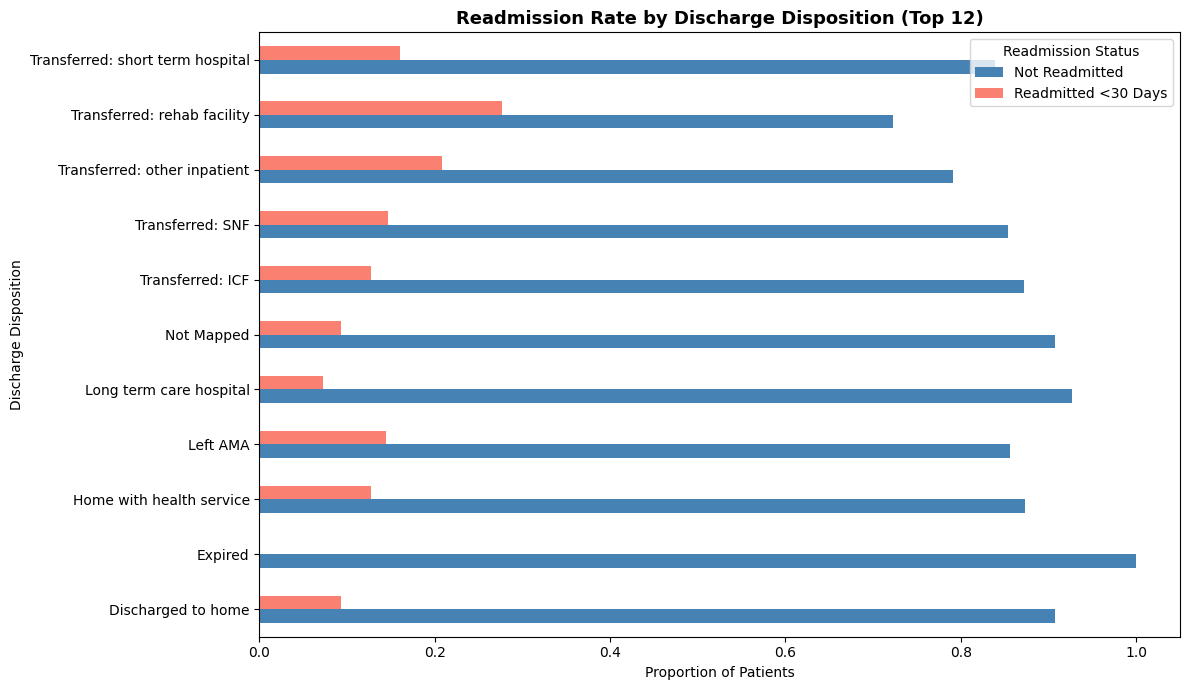

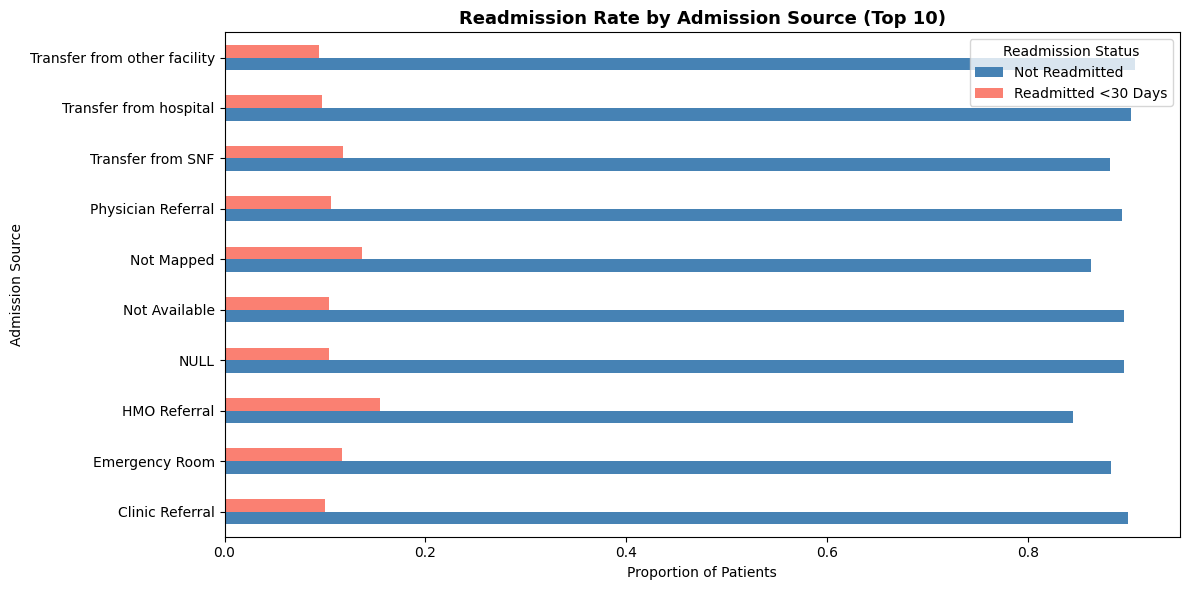

In [ ]:
# [4.3] Hospital Factors vs Readmission


admission_type_map = {
    1: "Emergency", 2: "Urgent", 3: "Elective", 4: "Newborn",
    5: "Not Available", 6: "NULL", 7: "Trauma Center", 8: "Not Mapped"
}
discharge_disposition_map = {
    1: "Discharged to home", 2: "Transferred: short term hospital",
    3: "Transferred: SNF", 4: "Transferred: ICF",
    5: "Transferred: other inpatient", 6: "Home with health service",
    7: "Left AMA", 8: "Home: IV provider", 9: "Admitted as inpatient",
    10: "Neonate to neonatal aftercare", 11: "Expired",
    12: "Still patient / outpatient return", 13: "Hospice / home",
    14: "Hospice / medical facility", 22: "Transferred: rehab facility",
    23: "Long term care hospital", 25: "Not Mapped", 26: "Unknown/Invalid",
    27: "Federal health care facility", 28: "Psychiatric hospital",
    29: "Critical Access Hospital", 30: "Other health care institution"
}
admission_source_map = {
    1: "Physician Referral", 2: "Clinic Referral", 3: "HMO Referral",
    4: "Transfer from hospital", 5: "Transfer from SNF",
    6: "Transfer from other facility", 7: "Emergency Room",
    8: "Court/Law Enforcement", 9: "Not Available",
    10: "Transfer from critical access", 17: "NULL",
    20: "Not Mapped", 21: "Unknown/Invalid",
    22: "Transfer from same facility", 25: "Transfer from ASC",
    26: "Transfer from Hospice"
}

df["admission_type_label"] = df["admission_type_id"].map(admission_type_map)
df["discharge_disposition_label"] = df["discharge_disposition_id"].map(discharge_disposition_map)
df["admission_source_label"] = df["admission_source_id"].map(admission_source_map)

# --- Admission Type ---
adm_tab = pd.crosstab(df["admission_type_label"], df["readmitted_binary"], normalize="index")
adm_tab.columns = ["Not Readmitted", "Readmitted <30 Days"]
adm_tab.plot(kind="barh", figsize=(10, 5), color=["steelblue", "salmon"])
plt.title("Readmission Rate by Admission Type", fontsize=13, fontweight="bold")
plt.xlabel("Proportion of Patients")
plt.ylabel("Admission Type")
plt.legend(title="Readmission Status")
plt.tight_layout()
plt.show()

# --- Discharge Disposition (top 12) ---
top_discharge = df["discharge_disposition_id"].value_counts().head(12).index
df_dis = df[df["discharge_disposition_id"].isin(top_discharge)].copy()
dis_tab = pd.crosstab(df_dis["discharge_disposition_label"], df_dis["readmitted_binary"], normalize="index")
dis_tab.columns = ["Not Readmitted", "Readmitted <30 Days"]
dis_tab.plot(kind="barh", figsize=(12, 7), color=["steelblue", "salmon"])
plt.title("Readmission Rate by Discharge Disposition (Top 12)", fontsize=13, fontweight="bold")
plt.xlabel("Proportion of Patients")
plt.ylabel("Discharge Disposition")
plt.legend(title="Readmission Status")
plt.tight_layout()
plt.show()

# --- Admission Source (top 10) ---
top_source = df["admission_source_id"].value_counts().head(10).index
df_src = df[df["admission_source_id"].isin(top_source)].copy()
src_tab = pd.crosstab(df_src["admission_source_label"], df_src["readmitted_binary"], normalize="index")
src_tab.columns = ["Not Readmitted", "Readmitted <30 Days"]
src_tab.plot(kind="barh", figsize=(12, 6), color=["steelblue", "salmon"])
plt.title("Readmission Rate by Admission Source (Top 10)", fontsize=13, fontweight="bold")
plt.xlabel("Proportion of Patients")
plt.ylabel("Admission Source")
plt.legend(title="Readmission Status")
plt.tight_layout()
plt.show()

### [4.4] Clinical Factors
Diagnosis groups and medication changes are important predictors. Patients with complex conditions or medication adjustments are more likely to be readmitted.


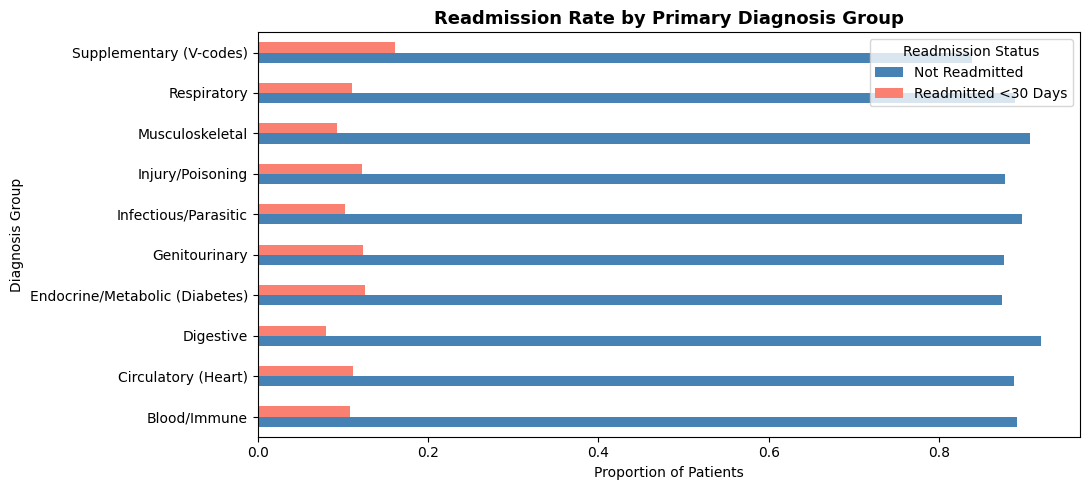

In [ ]:
# [4.4] Clinical Factors vs Readmission


diag_label_map = {
    "2": "Endocrine/Metabolic (Diabetes)",
    "4": "Circulatory (Heart)",
    "5": "Respiratory",
    "7": "Musculoskeletal",
    "8": "Genitourinary",
    "1": "Infectious/Parasitic",
    "3": "Blood/Immune",
    "6": "Digestive",
    "9": "Injury/Poisoning",
    "V": "Supplementary (V-codes)",
    "E": "External Causes (E-codes)"
}

top_diag = df["diag_1_group"].value_counts().head(10).index
df_diag = df[df["diag_1_group"].isin(top_diag)].copy()
df_diag["diag_label"] = df_diag["diag_1_group"].map(diag_label_map).fillna(df_diag["diag_1_group"])

diag_tab = pd.crosstab(df_diag["diag_label"], df_diag["readmitted_binary"], normalize="index")
diag_tab.columns = ["Not Readmitted", "Readmitted <30 Days"]
diag_tab.plot(kind="barh", figsize=(11, 5), color=["steelblue", "salmon"])
plt.title("Readmission Rate by Primary Diagnosis Group", fontsize=13, fontweight="bold")
plt.xlabel("Proportion of Patients")
plt.ylabel("Diagnosis Group")
plt.legend(title="Readmission Status")
plt.tight_layout()
plt.show()

# Medication change and diabetes medication side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

med_change = pd.crosstab(df["change"], df["readmitted_binary"], normalize="index")
med_change.columns = ["Not Readmitted", "Readmitted <30 Days"]
med_change.index = ["No Change", "Medication Changed"]
med_change.plot(kind="bar", stacked=True, ax=axes[0], color=["steelblue", "salmon"], rot=0)
axes[0].set_title("Readmission Rate by Medication Change", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Medication Change Status")
axes[0].set_ylabel("Proportion")
axes[0].legend(title="Readmission Status")

diab_med = pd.crosstab(df["diabetesMed"], df["readmitted_binary"], normalize="index")
diab_med.columns = ["Not Readmitted", "Readmitted <30 Days"]
diab_med.index = ["No Diabetes Medication", "On Diabetes Medication"]
diab_med.plot(kind="bar", stacked=True, ax=axes[1], color=["steelblue", "salmon"], rot=0)
axes[1].set_title("Readmission Rate by Diabetes Medication Use", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Diabetes Medication Status")
axes[1].set_ylabel("Proportion")
axes[1].legend(title="Readmission Status")

plt.tight_layout()
plt.show()

### [4.5] Feature Distributions
Histograms show that readmitted patients generally have higher values in hospital utilisation metrics.

In [ ]:
# [4.5] Feature Distributions by Readmission Status

features_num = [
    "time_in_hospital",
    "num_medications",
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
    "number_diagnoses"
]

feature_titles = {
    "time_in_hospital": "Time in Hospital (Days)",
    "num_medications": "Number of Medications",
    "number_inpatient": "Number of Inpatient Visits",
    "number_emergency": "Number of Emergency Visits",
    "number_outpatient": "Number of Outpatient Visits",
    "number_diagnoses": "Number of Diagnoses"
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, col in zip(axes, features_num):
    sns.kdeplot(data=df[df["readmitted_binary"]==0], x=col, ax=ax,
                fill=True, alpha=0.5, color="steelblue", label="Not Readmitted")
    sns.kdeplot(data=df[df["readmitted_binary"]==1], x=col, ax=ax,
                fill=True, alpha=0.5, color="salmon", label="Readmitted <30 Days")
    ax.set_title(feature_titles[col], fontsize=11, fontweight="bold")
    ax.set_xlabel(feature_titles[col])
    ax.set_ylabel("Density")
    ax.legend(title="Readmission Status", fontsize=8)

plt.suptitle("Distribution of Key Clinical Features by Readmission Status",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### [4.6] Correlation Analysis

A correlation heatmap was used to examine the relationships between numerical features and the target variable (readmitted within 30 days). This analysis helps identify the most relevant predictors and potential multicollinearity between variables.

Overall, most features show **weak to moderate correlations** with the target variable, indicating that no single variable strongly determines readmission. This supports the need for machine learning models that can capture complex, non-linear relationships.

One of the key findings is the strong correlation between the engineered feature *treatment_intensity* and its component variables:
- treatment_intensity and num_lab_procedures (r = 0.93)
- treatment_intensity and num_medications (r = 0.60)

This confirms that the composite feature successfully captures overall treatment complexity. Additionally, treatment_intensity shows a higher correlation with readmission compared to individual variables, suggesting that combined healthcare utilisation is a more meaningful predictor than isolated measures.

Moderate correlations are also observed between:
- time_in_hospital and num_medications (r ≈ 0.47)
- num_medications and readmission-related behaviour (positive trend)

These relationships indicate that patients requiring longer hospital stays and more medications tend to have more complex conditions, increasing the likelihood of readmission.

However, the heatmap also reveals **low correlations for many variables**, which suggests:
- The dataset contains diverse and independent features  
- Predictive performance will rely on combining multiple variables rather than a single dominant factor  

Importantly, the strong correlation between treatment_intensity and its components highlights a potential issue of **multicollinearity**, particularly for linear models such as Logistic Regression. This must be considered during model development to avoid redundancy and instability in coefficients.

From a business intelligence perspective, the analysis suggests that:
- Patient complexity (captured through treatment intensity and hospital utilisation) is a key driver of readmission risk  
- Simple rules based on single variables are insufficient for decision-making  
- Advanced predictive models are required to identify high-risk patients effectively  

This correlation analysis provides statistical evidence that supports the feature engineering approach and guides the selection of appropriate machine learning models in the next stage.

In [ ]:
# Correlation Heatmap

correlation_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "treatment_intensity",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "age_num",
    "change_bin",
    "diabetesMed_bin",
    "insulin_bin",
    "max_glu_serum_bin",
    "A1Cresult_bin",
    "readmitted_binary"
]

correlation_data = df[correlation_columns]


correlation_matrix = correlation_data.corr()


plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)


plt.title("Correlation Matrix of Key Features", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

##[5] Unsupervised Learning: K-Means Clustering

### Justification for K-Means
K-Means clustering is used to identify groups of patients with similar characteristics without predefined labels. This helps uncover hidden patterns and supports patient segmentation for targeted interventions.(Aurélien Géron, 2019)


### [5.1] Feature Selection
Relevant numerical features with sufficient variation are selected to ensure meaningful clustering.

In [ ]:
corr_target = correlation_matrix["readmitted_binary"].abs()

effective_features = corr_target[corr_target >= 0.05].index.tolist()

if "readmitted_binary" in effective_features:
    effective_features.remove("readmitted_binary")

km_features = [col for col in effective_features if df[col].nunique() > 2]

### [5.2] Data Scaling
Standardisation is applied to ensure all features contribute equally.

In [ ]:
#5.2
from sklearn.preprocessing import StandardScaler

df_km = df[km_features].dropna()
scaled_km = StandardScaler().fit_transform(df_km)

### [5.3] Elbow Method
The elbow method is used to determine the optimal number of clusters based on within-cluster variance.

In [ ]:
#5.3
from sklearn.cluster import KMeans

inertia = []
for k in range(2,10):
    inertia.append(KMeans(n_clusters=k, random_state=42).fit(scaled_km).inertia_)

plt.plot(range(2,10), inertia, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

### [5.4] Silhouette Score
Silhouette scores assess cluster quality by measuring separation and cohesion.

In [ ]:
# [5.4] Silhouette Score Comparison

from sklearn.metrics import silhouette_score

silhouette_results = []
for k in range(2, 5):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)
    labels_k = kmeans.fit_predict(scaled_km[:15000])
    score = silhouette_score(scaled_km[:15000], labels_k)
    silhouette_results.append({"K (Clusters)": k, "Silhouette Score": round(score, 4)})

sil_df = pd.DataFrame(silhouette_results).set_index("K (Clusters)")
print("Silhouette Scores by Number of Clusters:")
print(sil_df.to_string())

# Bar chart
sil_df.plot(kind="bar", figsize=(6, 4), color="steelblue", legend=False)
plt.title("Silhouette Score by Number of Clusters", fontsize=12, fontweight="bold")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### [5.5] PCA for Dimensionality Reduction
PCA reduces dimensionality and enables visualisation of clusters.(‘scikit-learn: machine learning in Python — scikit-learn 0.22.2 documentation’, n.d.)

In [ ]:
#5.5
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_2d = pca.fit_transform(scaled_km)

### [5.6] Cluster Visualisation
Clusters are visualised in two dimensions, showing clear separation between groups.

In [ ]:
# [5.6] Cluster Visualisation (PCA 2D)

km = KMeans(n_clusters=3, random_state=42)
labels = km.fit_predict(scaled_km)

cluster_names = {0: "Low-Risk", 1: "Moderate-Risk", 2: "High-Risk"}
label_names = [cluster_names[l] for l in labels]

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=pca_2d[:, 0], y=pca_2d[:, 1],
    hue=label_names,
    palette={"Low-Risk": "steelblue", "Moderate-Risk": "orange", "High-Risk": "salmon"},
    alpha=0.5, s=10
)
plt.title("Patient Clusters Visualised via PCA (K=3)", fontsize=13, fontweight="bold")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Risk Cluster", loc="upper right")
plt.tight_layout()
plt.show()

### [5.7] Cluster Profiling & Insights
Clusters reveal distinct patient segments:
- Low-risk patients with minimal hospital use
- Moderate-risk patients with some complexity
- High-risk patients with frequent visits and multiple conditions

These insights support targeted healthcare strategies.

In [ ]:
# [5.7] Cluster Profiling & Risk Analysis

km_model_for_profiling = KMeans(n_clusters=3, random_state=42, n_init='auto')
current_cluster_labels = km_model_for_profiling.fit_predict(scaled_km)

# Assign the cluster labels to the original DataFrame 'df'
# Only rows that were part of the clustering (i.e., those in df_km.index) receive a cluster ID.
# Rows not included in df_km (due to NaNs) will have NaN in the 'cluster' column initially.
df.loc[df_km.index, "cluster"] = current_cluster_labels


df["cluster"] = df["cluster"].fillna(-1).astype(int)

# Extend the cluster_names dictionary to include the '-1' category for unclustered data.
# 'cluster_names' is assumed to be available from cell VlDRODTh-yj2.
# If not, it should be defined here, e.g.: cluster_names = {0: "Low-Risk", 1: "Moderate-Risk", 2: "High-Risk"}
cluster_names[-1] = "Unclustered"

cluster_profile = df.groupby("cluster")[km_features].mean().round(3)
# Map the numerical cluster IDs in the index to descriptive names.
cluster_profile.index = [cluster_names[idx] for idx in cluster_profile.index]

print("Mean Feature Values per Cluster:")
display(cluster_profile.style
    .background_gradient(cmap="Blues", axis=0)
    .set_caption("Cluster Profiling: Mean Feature Values")
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding", "8px")]
    }])
)

# Readmission rate per cluster
readmission_by_cluster = df.groupby("cluster")["readmitted_binary"].mean().round(3)
# Map the numerical cluster IDs in the index to descriptive names.
readmission_by_cluster.index = [cluster_names[idx] for idx in readmission_by_cluster.index]

# Prepare colors for the bar chart, including a color for the 'Unclustered' group if present.
plot_colors = [
    "steelblue" if name == "Low-Risk" else
    "orange" if name == "Moderate-Risk" else
    "salmon" if name == "High-Risk" else
    "gray" # For "Unclustered"
    for name in readmission_by_cluster.index
]

plt.figure(figsize=(7, 4))
readmission_by_cluster.plot(kind="bar", color=plot_colors, edgecolor="white")
plt.title("Readmission Rate per Patient Cluster", fontsize=12, fontweight="bold")
plt.xlabel("Patient Risk Cluster")
plt.ylabel("Proportion Readmitted within 30 Days")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##[6] Predictive Modelling
Predictive modelling techniques are widely used in healthcare analytics to support decision-making and identify high-risk patients based on historical data patterns (Kourou et al., 2015).


In [ ]:
# [6] Predictive Modelling

from sklearn.model_selection import train_test_split

cols_to_drop_from_X = [
    "readmitted_binary",
    "age",
    "change",
    "diabetesMed",
    "A1Cresult",
    "max_glu_serum",
    "insulin",
    "diag_1"
]

X = df.drop(cols_to_drop_from_X, axis=1)
y = df["readmitted_binary"]

categorical_cols = X.select_dtypes(include='object').columns
X = pd.get_dummies(X, columns=categorical_cols, dummy_na=False)
X = X.fillna(0)

### [6.1] Train-Test Split
The dataset is split into training and testing sets using stratification to preserve class distribution.


In [ ]:
# 6.1 Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


### [6.2] Logistic Regression (Baseline)
Logistic Regression is commonly used as a baseline classification model due to its interpretability and ability to model probability-based outcomes (Hosmer et al., 2013).



In [ ]:
# 6.2 Logistic Regression (Baseline)


from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]



### [6.3] Decision Tree
Decision Trees are effective for capturing non-linear relationships and provide transparent decision rules, making them suitable for healthcare applications where interpretability is important (Quinlan, 1986).



In [ ]:
# 6.3 Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]



### [6.4] Random Forest (Main Model)
Random Forest improves predictive performance by combining multiple decision trees, reducing overfitting and increasing model robustness (Breiman, 2001).

In [ ]:
# 6.4 Random Forest (Main Model)


from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

### [6.5] Model & Predictions Registry

In [ ]:
# 6.5 Model & Predictions Registry


from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "Logistic Regression": log_model,
    "Decision Tree":       dt_model,
    "Random Forest":       rf_model
}

predictions = {
    "Logistic Regression": y_pred_log,
    "Decision Tree":       y_pred_dt,
    "Random Forest":       y_pred_rf
}

###[6.6] Confusion Matrix Comparison

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model_name in zip(axes, models.keys()):
    cm = confusion_matrix(y_test, predictions[model_name])

    # Add TN FP FN TP labels
    labels = np.array([
        ["TN", "FP"],
        ["FN", "TP"]
    ])

    annotated = np.empty_like(cm).astype(str)

    for i in range(2):
        for j in range(2):
            annotated[i, j] = f"{labels[i, j]}\n{cm[i, j]}"

    sns.heatmap(
        cm,
        annot=annotated,
        fmt="",
        cmap="YlGnBu",
        cbar=False,
        linewidths=1,
        linecolor="black",
        ax=ax
    )

    ax.set_title(model_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticklabels(["No", "Yes"])
    ax.set_yticklabels(["No", "Yes"], rotation=0)

plt.suptitle("Confusion Matrix Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

##[7] Model Evaluation
Model performance is evaluated using multiple metrics, as relying solely on accuracy can be misleading in imbalanced datasets (Saito and Rehmsmeier, 2015).

### [7.1] Model Performance Comparison

In [ ]:
# Model Performance Comparison Table


from sklearn.metrics import classification_report
import pandas as pd

rows = []

for model_name, y_pred in predictions.items():
    report = classification_report(y_test, y_pred, output_dict=True)
    rows.append({
        "Model":             model_name,
        "Accuracy":          round(report["accuracy"], 3),
        "Precision (0)":     round(report["0"]["precision"], 3),
        "Recall (0)":        round(report["0"]["recall"], 3),
        "F1-Score (0)":      round(report["0"]["f1-score"], 3),
        "Precision (1)":     round(report["1"]["precision"], 3),
        "Recall (1)":        round(report["1"]["recall"], 3),
        "F1-Score (1)":      round(report["1"]["f1-score"], 3),
        "Macro F1":          round(report["macro avg"]["f1-score"], 3),
        "Weighted F1":       round(report["weighted avg"]["f1-score"], 3),
    })

perf_df = pd.DataFrame(rows).set_index("Model")

perf_df.style \
    .background_gradient(cmap="Blues", axis=0) \
    .format("{:.3f}") \
    .set_caption("Model Performance Comparison") \
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "16px"), ("font-weight", "bold"), ("padding", "10px")]
    }])

### [7.2] ROC-AUC and Precision-Recall Analysis

ROC-AUC is widely used to evaluate classification performance across thresholds; however, Precision-Recall analysis is more informative in imbalanced datasets, as it focuses on the minority class performance (Saito and Rehmsmeier, 2015).

However, due to the class imbalance (~11% readmission rate), the Precision-Recall curve provides a more informative evaluation. It focuses on the model’s ability to correctly identify high-risk patients while balancing false positives.

The Random Forest model demonstrates stronger performance in both ROC-AUC and Precision-Recall analysis, indicating its effectiveness in distinguishing and identifying readmission cases. This confirms its suitability for healthcare applications where detecting high-risk patients is critical.

In [ ]:
# [7.2] ROC + Precision-Recall

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Probabilities
y_proba_log = log_model.predict_proba(X_test)[:, 1]
y_proba_dt  = dt_model.predict_proba(X_test)[:, 1]
y_proba_rf  = rf_model.predict_proba(X_test)[:, 1]

# ROC calculations
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_dt,  tpr_dt,  _ = roc_curve(y_test, y_proba_dt)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_proba_rf)

roc_auc_log = auc(fpr_log, tpr_log)
roc_auc_dt  = auc(fpr_dt,  tpr_dt)
roc_auc_rf  = auc(fpr_rf,  tpr_rf)

# PR calculations
prec_log, rec_log, _ = precision_recall_curve(y_test, y_proba_log)
prec_dt,  rec_dt,  _ = precision_recall_curve(y_test, y_proba_dt)
prec_rf,  rec_rf,  _ = precision_recall_curve(y_test, y_proba_rf)

ap_log = average_precision_score(y_test, y_proba_log)
ap_dt  = average_precision_score(y_test, y_proba_dt)
ap_rf  = average_precision_score(y_test, y_proba_rf)

baseline = y_test.mean()

# Create combined figure
plt.figure(figsize=(14,6))

# -------- LEFT: ROC --------
plt.subplot(1, 2, 1)
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_log:.3f})")
plt.plot(fpr_dt,  tpr_dt,  label=f"Decision Tree (AUC = {roc_auc_dt:.3f})")
plt.plot(fpr_rf,  tpr_rf,  label=f"Random Forest (AUC = {roc_auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

# -------- RIGHT: PR --------
plt.subplot(1, 2, 2)
plt.plot(rec_log, prec_log, label=f"Logistic Regression (AP = {ap_log:.3f})")
plt.plot(rec_dt,  prec_dt,  label=f"Decision Tree (AP = {ap_dt:.3f})")
plt.plot(rec_rf,  prec_rf,  label=f"Random Forest (AP = {ap_rf:.3f})")
plt.axhline(y=baseline, linestyle="--", label=f"Baseline ({baseline:.3f})")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.tight_layout()
plt.show()

### [7.3] Feature Importance
Feature importance techniques help identify key predictors and enhance model interpretability, which is essential in healthcare decision-support systems (Lundberg and Lee, 2017).

In [ ]:
# [7.3] Top 20 Feature Importances (Random Forest)


importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(10, 8))
importances.tail(20).plot(kind="barh", color="steelblue")
plt.title("Top 20 Most Important Features for Predicting Readmission\n(Random Forest)",
          fontsize=13, fontweight="bold")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### [7.4] Prediction Probability Distribution
This shows the confidence of predictions and helps assess model reliability.

In [ ]:
# [7.4] Prediction Probability Distribution (Random Forest)


plt.figure(figsize=(9, 4))
plt.hist(y_proba_rf[y_test == 0], bins=40, alpha=0.6, color="steelblue", label="Not Readmitted")
plt.hist(y_proba_rf[y_test == 1], bins=40, alpha=0.6, color="salmon",    label="Readmitted <30 Days")
plt.axvline(x=0.5, linestyle="--", color="black", label="Default Threshold (0.5)")
plt.title("Predicted Probability Distribution by Actual Class (Random Forest)",
          fontsize=12, fontweight="bold")
plt.xlabel("Predicted Probability of Readmission")
plt.ylabel("Number of Patients")
plt.legend(title="Actual Outcome")
plt.tight_layout()
plt.show()


### [7.5] Threshold Tuning
Adjusting classification thresholds allows models to balance precision and recall depending on domain-specific requirements, particularly in healthcare where missing high-risk cases can have serious consequences (Fawcett, 2006).

In [ ]:
# [7.5] Threshold Tuning — Precision vs Recall Trade-off (Random Forest)

thresholds = np.arange(0.1, 0.9, 0.05)
precisions, recalls, f1_scores = [], [], []

for t in thresholds:
    yt = (y_proba_rf >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    precisions.append(precision_score(y_test, yt, zero_division=0))
    recalls.append(recall_score(y_test, yt, zero_division=0))
    f1_scores.append(f1_score(y_test, yt, zero_division=0))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, label="Precision", color="steelblue", marker="o")
plt.plot(thresholds, recalls,    label="Recall",    color="salmon",    marker="o")
plt.plot(thresholds, f1_scores,  label="F1-Score",  color="green",     marker="o")
plt.axvline(x=0.3, linestyle="--", color="gray", label="Recommended Threshold (0.3)")
plt.title("Precision, Recall & F1-Score vs Decision Threshold (Random Forest)",
          fontsize=12, fontweight="bold")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

print("\nBusiness Recommendation:")
print("A threshold of ~0.3 increases recall for high-risk patients (class 1),")
print("reducing missed readmissions at the cost of some false positives.")
print("This is the preferred trade-off in a healthcare setting.")


## [8] Model Comparison

The three models were evaluated using accuracy, precision, recall, and F1-score, with particular emphasis on performance for the positive class (readmitted patients).

Random Forest achieved the highest accuracy (0.889), significantly outperforming Logistic Regression (0.653) and Decision Tree (0.631). However, due to class imbalance (~11% readmission rate), accuracy alone is not a reliable indicator of performance.

Logistic Regression and Decision Tree both achieved very high precision (~0.927–0.928), meaning that when they predict a patient will be readmitted, they are usually correct. However, this comes at the cost of lower recall, indicating that many actual readmission cases are not detected.

In contrast, Random Forest provides a better balance between precision (0.889) and recall, resulting in a stronger F1-score for the positive class. This makes it more effective in identifying high-risk patients.

From a business perspective, recall is more critical than precision, as missing a high-risk patient (false negative) can lead to avoidable hospital readmissions and increased costs.

Therefore, Random Forest is selected as the final model, as it provides the most reliable and actionable predictions for healthcare decision-making.

## [9] Business Insights & Recommendations

The analysis identifies patient complexity, hospital utilisation, and treatment intensity as the key drivers of 30-day readmission risk.

### High-Risk Patient Identification
The Random Forest model (accuracy: 0.889) enables hospitals to identify high-risk patients before discharge. Patients with frequent inpatient visits, multiple emergency admissions, longer hospital stays, and high treatment intensity are significantly more likely to be readmitted.

By targeting this group, hospitals can prioritise interventions where they will have the greatest impact.

### Discharge Planning Improvements
EDA results show that certain discharge pathways (e.g., discharge to rehabilitation or without structured support) are associated with higher readmission rates.

Hospitals should implement enhanced discharge planning for these patients, including:
- Scheduled follow-up appointments  
- Remote monitoring programmes  
- Post-discharge support services  

This can reduce avoidable readmissions and improve patient outcomes.

### Medication Management
Patients with higher numbers of medications and recent treatment changes show increased readmission risk. This reflects treatment complexity and potential issues with medication adherence.

Hospitals should introduce pharmacist-led medication reconciliation and patient education at discharge to minimise complications.

### Cluster-Based Targeting
K-Means clustering identified three patient segments (low, moderate, and high risk). This allows hospitals to move from a one-size-fits-all approach to a targeted strategy, allocating resources more efficiently to high-risk groups.

### Model Deployment Strategy
Given the class imbalance (11% readmission rate), a lower decision threshold (0.3) is recommended for the Random Forest model in practice. This increases recall, ensuring that more high-risk patients are identified.

Although this may increase false positives, the cost of additional follow-up is significantly lower than the cost of hospital readmission, making this a cost-effective strategy.

Overall, the use of predictive analytics can support proactive healthcare management, reduce operational costs, and improve patient care quality.

## [10] Limitations

### Data and Temporal Scope
The dataset covers 130 US hospitals between 1999 and 2008. This historical scope limits generalisability to modern clinical settings, where treatment protocols, medication options, and hospital workflows have changed considerably. Findings may also not transfer directly to non-US healthcare systems with different funding models or patient demographics.

### Class Imbalance
Approximately 11% of encounters result in a 30-day readmission, creating a significant class imbalance. Despite applying `class_weight="balanced"` across all models and lowering the decision threshold to 0.3, the models remain more effective at identifying non-readmission cases. Recall for the positive class should therefore be interpreted with this limitation in mind.

### Missing Clinical Variables
Several clinically important factors are absent from the dataset, including patient lifestyle (diet, activity levels, smoking), socioeconomic conditions (income, housing stability), medication adherence records, and mental health comorbidities. The exclusion of these variables limits the completeness of the model and may reduce its predictive performance in real-world settings.

### Model Interpretability
Random Forest, while the strongest-performing model, is a black-box ensemble method. Although feature importance scores provide some directional insight, individual predictions cannot be fully explained. This may reduce clinician trust and limit adoption in clinical environments where transparency and explainability are required for safe decision-making.

## [11] Ethical, Privacy, and Security Considerations

### Algorithmic Bias and Fairness
The dataset includes demographic variables such as age, gender, and race. If these variables directly influence model predictions, there is a risk that the model may reflect existing healthcare disparities rather than genuine clinical risk. This could result in systematically different predictions across patient groups, potentially disadvantaging already marginalised populations.

To mitigate this, any deployed system should regularly audit predictions across demographic subgroups, apply fairness-aware techniques where appropriate, and avoid using sensitive attributes as primary predictive features unless clinically justified.

### Patient Data Privacy
Healthcare data is among the most sensitive categories of personal information. Although the dataset used in this project is anonymised in accordance with HIPAA Safe Harbour guidelines, anonymisation alone does not fully eliminate re-identification risks — particularly when multiple quasi-identifiers such as age, diagnosis group, and admission type are combined.

Any real-world deployment must comply with applicable data protection legislation. Under GDPR, organisations must establish a lawful basis for processing health data, apply data minimisation principles, and ensure individuals can exercise their rights, including the right to erasure and the right to access. Under HIPAA, appropriate safeguards for protected health information (PHI) are mandatory, including access controls and audit trails.

### Transparency and Automated Decision-Making
Under GDPR Article 22, individuals have the right not to be subject to solely automated decisions that significantly affect them. In a clinical context, model outputs must function as decision-support tools — supplementing, not replacing, clinician judgement. Patients should be informed when algorithmic risk scores influence their care, and clinicians must retain full accountability for all treatment decisions.

### Informed Consent
Where patient data is used beyond its original clinical purpose — such as for predictive modelling or research — appropriate ethical approval and consent processes must be in place. Patients must be able to withdraw consent and have their data excluded from future model training cycles.

### System Security
Any deployed system handling patient data must implement robust security controls, including encryption of data at rest and in transit, role-based access controls to restrict data access to authorised personnel only, full audit logging of all data queries and model outputs, and regular vulnerability assessments. In the event of a data breach, GDPR requires notification within 72 hours. Failure to address these requirements could compromise patient confidentiality, expose the organisation to legal liability, and erode public trust.

## [12] Conclusion

This project developed a business intelligence solution to predict 30-day hospital readmissions among diabetic patients using real-world healthcare data. Exploratory analysis revealed that readmission risk is strongly associated with patient complexity, prior hospital utilisation, and treatment intensity.

Feature engineering enhanced the analytical depth of the study, particularly through the creation of the *treatment_intensity* variable, which provided a more comprehensive representation of care complexity than individual features. The correlation and EDA findings further demonstrated that no single variable dominates prediction, reinforcing the need for multi-factor modelling approaches.

Among the models evaluated, Random Forest achieved the strongest overall performance (accuracy: 0.889) and delivered the most effective balance between precision and recall. This makes it the most suitable model for identifying high-risk patients, especially in a healthcare context where missing a readmission case carries significant clinical and financial consequences.

From a business intelligence perspective, the findings highlight clear opportunities for improving hospital operations. Predictive models can be used to identify high-risk patients prior to discharge, enabling targeted interventions such as enhanced follow-up care, improved discharge planning, and more effective medication management. Additionally, clustering analysis supports more efficient resource allocation by segmenting patients into risk-based groups rather than applying uniform care strategies.

Overall, this project demonstrates the value of data-driven decision-making in healthcare. By integrating predictive analytics into clinical workflows, hospitals can reduce avoidable readmissions, optimise resource utilisation, and improve patient outcomes.

## [13] References

Aurélien Géron (2019) Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow. Sebastopol: O’Reilly Media.

Beauchamp, T.L. and Childress, J.F. (2019) Principles of biomedical ethics. 8th edn. Oxford: Oxford University Press.

Bertsimas, D., Bjarnadóttir, M.V., Kane, M.A., Kryder, J.C., Pandey, R., Vempala, S. and Wang, G. (2008) Algorithmic prediction of health-care costs. Operations Research [online]. 56 (6), pp. 1382–1392.

Breiman, L. (2001) Random forests. Machine Learning [online]. 45 (1), pp. 5–32.

Calvillo–King, L., Arnold, D., Eubank, K., Lo, M., Yunyongying, P., Stieglitz, H. and Halm, E.A. (2013) Impact of social factors on risk of readmission. Journal of General Internal Medicine [online]. 28 (2), pp. 269–282.

Coleman, E.A., Parry, C., Chalmers, S. and Min, S.J. (2006) The care transitions intervention. Archives of Internal Medicine [online]. 166 (17), pp. 1822–1828.

Doshi-Velez, F. and Kim, B. (2017) Towards a rigorous science of interpretable machine learning. arXiv preprint [online]. Available from: https://arxiv.org/abs/1702.08608

El Emam, K., Jonker, E., Arbuckle, L. and Malin, B. (2011) A systematic review of re-identification attacks on health data. PLoS ONE [online]. 6 (12).

Fawcett, T. (2006) An introduction to ROC analysis. Pattern Recognition Letters [online]. 27 (8), pp. 861–874.

García-Pérez, L., Linertová, R., Lorenzo-Riera, A., Vázquez-Díaz, J.R., Duque-González, B. and Sarría-Santamera, A. (2011) Risk factors for hospital readmissions. BMC Health Services Research [online]. 11 (1).

Goodman, B. and Flaxman, S. (2017) European Union regulations on algorithmic decision-making and a “right to explanation”. AI Magazine [online]. 38 (3), pp. 50–57.

He, H. and Garcia, E.A. (2009) Learning from imbalanced data. IEEE Transactions on Knowledge and Data Engineering [online]. 21 (9), pp. 1263–1284.

Hosmer, D.W., Lemeshow, S. and Sturdivant, R.X. (2013) Applied logistic regression. 3rd edn. New York: Wiley.

Jencks, S.F., Williams, M.V. and Coleman, E.A. (2009) Rehospitalizations among patients in the Medicare fee-for-service program. New England Journal of Medicine [online]. 360 (14), pp. 1418–1428.

Kourou, K., Exarchos, T.P., Exarchos, K.P., Karamouzis, M.V. and Fotiadis, D.I. (2015) Machine learning applications in cancer prognosis and prediction. Computational and Structural Biotechnology Journal [online]. 13, pp. 8–17.

Kripalani, S., LeFevre, F., Phillips, C.O., Williams, M.V., Basaviah, P. and Baker, D.W. (2007) Deficits in communication and information transfer between hospital-based and primary care physicians. JAMA [online]. 297 (8), pp. 831–841.

Kulkarni, S. and Harman, G. (2011) An elementary introduction to statistical learning theory. Hoboken: Wiley.

Lundberg, S.M. and Lee, S.I. (2017) A unified approach to interpreting model predictions. Advances in Neural Information Processing Systems [online]. 30.

McKinney, W. (2013) Python for data analysis. Beijing: O’Reilly.

Obermeyer, Z., Powers, B., Vogeli, C. and Mullainathan, S. (2019) Dissecting racial bias in an algorithm used to manage the health of populations. Science [online]. 366 (6464), pp. 447–453.

Quinlan, J.R. (1986) Induction of decision trees. Machine Learning [online]. 1 (1), pp. 81–106.

Rajkomar, A., Dean, J. and Kohane, I. (2019) Machine learning in medicine. New England Journal of Medicine [online]. 380 (14), pp. 1347–1358.

Saito, T. and Rehmsmeier, M. (2015) The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. PLoS ONE [online]. 10 (3).

Strack, B., DeShazo, J.P., Gennings, C., Olmo, J.L., Ventura, S., Cios, K.J. and Clore, J.N. (2014) Impact of HbA1c measurement on hospital readmission rates. BioMed Research International [online].

Voigt, P. and Von dem Bussche, A. (2017) The EU General Data Protection Regulation (GDPR): A practical guide. Cham: Springer.

Zheng, B., Zhang, J., Yoon, S.W., Lam, S.S., Khasawneh, M. and Poranki, S. (2015) Predictive modeling of hospital readmissions using metaheuristics and data mining. Journal of Biomedical Informatics [online]. 53, pp. 3–14.

‘Scikit-learn: machine learning in Python — scikit-learn documentation’ (no date) scikit-learn.org [online]. Available from: https://scikit-learn.org